# Nonlinear Mean

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from collections import deque
import torch

In [2]:
def RGD(
    f_hat: Callable,
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    proj_theta: Callable = lambda x: x,
    n: int = 500,
    eta: float = 0.1,
    tol: float = 1e-5,
    max_iter: int = 30
):

    all_thetas = [theta_0.clone().detach().squeeze()]
    
    theta_t = theta_0
    converged = False
    t = 0
    
    while not converged and t < max_iter:
        # Draw n samples from D(theta)
        z = D_theta(theta_t, n)
        
        # Compute gradient of loss (dL1)
        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad
        
        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * dL1)
        
        all_thetas.append(theta_t.detach().squeeze())
        
        # Check convergence
        if dL1.norm() < tol: 
            converged = True
        
        t += 1
    
    return theta_t, all_thetas

In [3]:
def PerfGD(
    f_hat: Callable,
    grad2_est: Callable,
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    proj_theta: Callable = lambda x: x,
    n: int = 500,
    eta: float = 0.1,
    warmup: int = 1,
    tol: float = 1e-5,
    max_iter: int = 30
):
    
    all_thetas = [theta_0.clone().detach().squeeze()]

    # Use unlimited history instead of fixed H
    theta_history = []
    f_history = []

    # Take only 1 step of RGD for initialization
    theta_t = theta_0
    z = D_theta(theta_t, n) # Draw n samples from D(theta)
    f_t = f_hat(z)  # Estimate for f(theta)

    theta_history.append(theta_t.detach())
    f_history.append(f_t.detach())

    # One gradient descent step on Loss_1 loss
    theta_t.requires_grad_(True)
    theta_t.grad = None 
    l_t = loss(z, theta_t).mean(dim=-1)
    l_t.backward()
    dL1 = theta_t.grad

    with torch.no_grad():
        theta_t = proj_theta(theta_t - eta * dL1)

    all_thetas.append(theta_t.detach().squeeze())

    # Now run with full gradient update using entire history
    converged = False
    t = 1
    while not converged:

        z = D_theta(theta_t, n) # Draw n samples from D(theta) (d x n)
        f_t = f_hat(z) # (d,)
        
        theta_history.append(theta_t.detach())
        f_history.append(f_t.detach())

        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad
        
        # Use entire history (not just last H steps)
        if len(theta_history) >= 2:  # Need at least 2 points for gradient estimation
            Theta_full = torch.stack([th for th in theta_history], dim=1)   # (p, t+1)
            F_full = torch.stack([fh for fh in f_history], dim=1)   # (q, t+1)
            
            Theta = Theta_full[:, :-1]                                      # (p, t) -> 0 : t-1
            F = F_full[:, :-1]
            oneH = torch.ones(1, Theta.shape[1], device=Theta.device)

            delta_theta = Theta - theta_t.unsqueeze(1) @ oneH          # (p, t)
            delta_f = F - f_t.unsqueeze(1) @ oneH          # (q, t)

            df_d_theta = delta_f @ torch.linalg.pinv(delta_theta) # (p x q)

            dL2 = grad2_est(z, f_t, theta_t, df_d_theta)
        else:
            dL2 = torch.zeros_like(dL1)  # No performative correction if not enough history

        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * (dL1 + dL2))

        all_thetas.append(theta_t.detach().squeeze())
        
        if (dL1 + dL2).norm() < tol: 
            break # Converged
        
        t += 1
        if t > max_iter: 
            break # Max iterations
    
    return theta_t, all_thetas

In [4]:
def run_experiment():
    a0 = 1.0
    a1 = 1.0
    sigma = torch.tensor([[1.0]])
    mu = lambda theta: torch.sqrt(a0*theta + a1) # Define mean function (determines performativity)
    f_hat = lambda z: z.mean(dim=1)
    D_theta = lambda theta, n: torch.normal(mu(theta).squeeze(), 1.0, size=(1,n))
    loss = lambda z, theta: z*theta
    def grad2_est(z, f, theta, df_d_theta):
        if z.ndim == 1: z = z.unsqueeze(0)
        if f.ndim == 1: f = f.unsqueeze(0)
        return torch.mean( loss(z, theta) * (df_d_theta.T @ torch.linalg.inv(sigma) @ (z - f)), dim=-1)

    proj_theta = lambda x: x.clamp(min=-1.0, max=1.0)

    # Run 5 trials
    num_trials = 5
    all_rgd_trajectories = []
    all_perfgd_trajectories = []
    rgd_final_thetas = []
    perfgd_final_thetas = []

    print(f"Running {num_trials} trials...")

    for trial in range(num_trials):
        print(f"Trial {trial + 1}/{num_trials}")
        
        # Run RGD
        theta_rgd, all_theta_rgd = RGD(
            f_hat,
            D_theta,
            loss,
            theta_0 = torch.tensor([0.0]),
            proj_theta = proj_theta,
            n = 500,
            eta = 0.1,
            tol = 1e-5,
            max_iter = 30
        )

        # Run PerfGD
        theta_perfgd, all_theta_perfgd = PerfGD(
            f_hat,
            grad2_est,
            D_theta,
            loss,
            theta_0 = torch.tensor([0.0]),
            proj_theta = proj_theta,
            n = 500,
            eta = 0.1,
            tol = 1e-5,
            max_iter = 30
        )
        
        # Store results
        all_rgd_trajectories.append(all_theta_rgd)
        all_perfgd_trajectories.append(all_theta_perfgd)
        rgd_final_thetas.append(theta_rgd.item())
        perfgd_final_thetas.append(theta_perfgd.item())

    print(f"All trials completed!")

    # Compute average trajectories
    max_length = max(len(traj) for traj in all_rgd_trajectories + all_perfgd_trajectories)
    avg_rgd_trajectory = []
    avg_perfgd_trajectory = []

    for i in range(max_length):
        rgd_values = []
        perfgd_values = []
        
        for traj in all_rgd_trajectories:
            if i < len(traj):
                rgd_values.append(traj[i].item())
        
        for traj in all_perfgd_trajectories:
            if i < len(traj):
                perfgd_values.append(traj[i].item())
        
        if rgd_values:
            avg_rgd_trajectory.append(np.mean(rgd_values))
        if perfgd_values:
            avg_perfgd_trajectory.append(np.mean(perfgd_values))

    # Plot results
    plt.figure(figsize=(12, 8))

    # Plot average trajectories
    if len(avg_rgd_trajectory) > 0:
        plt.plot(avg_rgd_trajectory, label='RGD (Average)', linewidth=3, color='purple')
    else:
        print("Warning: RGD average trajectory is empty")

    if len(avg_perfgd_trajectory) > 0:
        plt.plot(avg_perfgd_trajectory, label='PerfGD (Average)', linewidth=3, color='orange')
    else:
        print("Warning: PerfGD average trajectory is empty")

    # Plot individual trajectories with transparency
    for i, traj in enumerate(all_rgd_trajectories):
        if len(traj) > 0:
            plt.plot(torch.stack(traj), alpha=0.3, color='purple', linewidth=1)

    for i, traj in enumerate(all_perfgd_trajectories):
        if len(traj) > 0:
            plt.plot(torch.stack(traj), alpha=0.3, color='orange', linewidth=1)

    # Add theoretical solutions
    theta_opt = -2*a0/(3*a1)
    theta_stab = -a0/a1

    plt.axhline(y=theta_opt, color='r', linestyle='dashed', linewidth=2, label='θOPT (Theoretical)')
    plt.axhline(y=theta_stab, color='b', linestyle='dashed', linewidth=2, label='θSTAB (Theoretical)')

    plt.legend(fontsize=12)
    plt.title('RGD vs PerfGD on Performative Mean Estimation (5 Trials Average)', fontsize=14)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel(r'$\theta$', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print summary statistics
    print(f"\nSummary Statistics ({num_trials} trials):")
    print(f"RGD final theta - Mean: {np.mean(rgd_final_thetas):.6f}, Std: {np.std(rgd_final_thetas):.6f}")
    print(f"PerfGD final theta - Mean: {np.mean(perfgd_final_thetas):.6f}, Std: {np.std(perfgd_final_thetas):.6f}")
    print(f"Theoretical θOPT: {theta_opt:.6f}")
    print(f"Theoretical θSTAB: {theta_stab:.6f}")

Running 5 trials...
Trial 1/5
Trial 2/5
Trial 3/5
Trial 4/5
Trial 5/5
All trials completed!


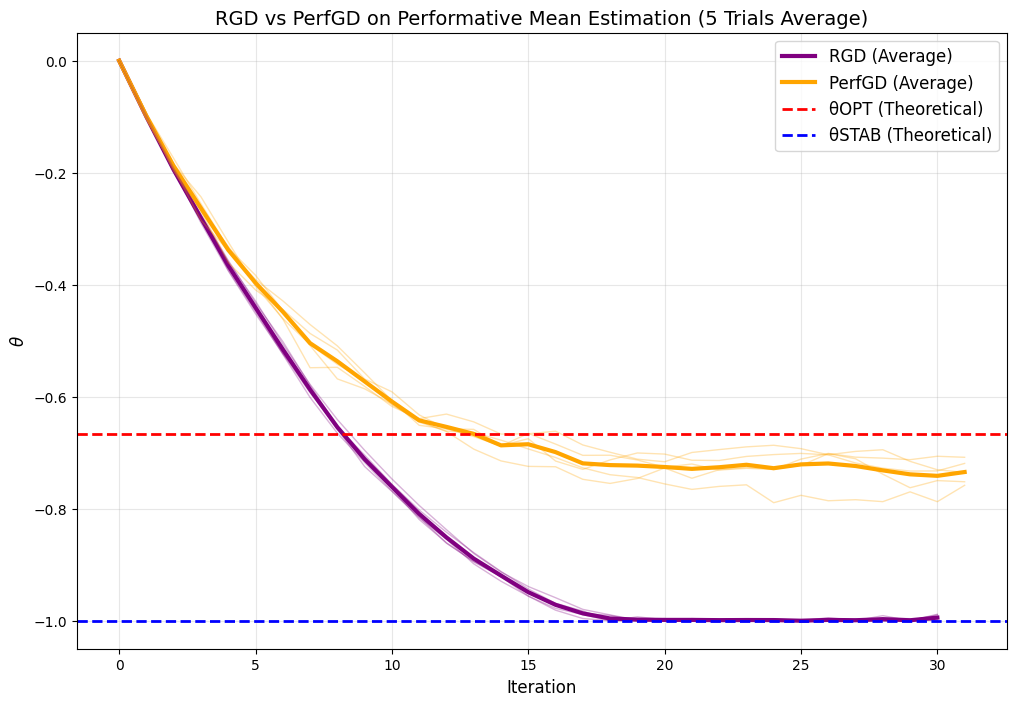


Summary Statistics (5 trials):
RGD final theta - Mean: -0.994437, Std: 0.004649
PerfGD final theta - Mean: -0.734485, Std: 0.018938
Theoretical θOPT: -0.666667
Theoretical θSTAB: -1.000000


In [5]:
run_experiment()